# Goals

Optimasi campaign result terkait penawaran produk baru, sehingga mendapatkan profit yang maksimal di bulan depan dan memahami karakteristik customers yang menerima penawaran produk baru tersebut.

# EXPLORATORY ANALYSIS

## Membaca File

In [1]:
# Mendeklarasikan library yang akan digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Menampilkan semua kolom
pd.set_option('display.max.columns',None)

# Menampilkan data kolom dan baris di csv
data = pd.read_csv('raw_data.csv')
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0


## Data Quality Check

### Question 1
Apakah ada features (kolom) yang type datanya tidak sama?

#### Langkah 1 : Menghapus Kolom yang Tidak Digunakan

In [3]:
data = data.drop(['Z_CostContact','Z_Revenue'], axis=1)
data

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,0
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,0


#### Langkah 2 : Mengecek Tipe Data

In [4]:
# Cara pertama yaitu menggunakan .info()
# Mengecek type data yang digunakan pada setiap kolomnya
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
# Cara kedua dengan membuat perulangan untuk menampilkan data berdasarkan type data pada setiap kolomnya
for dtype, col in (list(zip(data.dtypes, data.columns))):
    # Membuat pilihan jika data int dan float maka tampilkan kolom dan type data
    # serta menampilkan data minimal dan maximal saja karena data terlalu banyak jika ditampilkan semua
    if dtype == 'int64' or dtype == 'float64':
        print(col,dtype)
        print(data[col].min(), data[col].max())
    # Membuat pilihan lain jika selain data diatas maka tampilkan kolom dan type data
    # serta menampilkan data pada setiap kolomnya yang bernilai unique (berbeda dengan yang lain)
    else:
        print(col, dtype)
        print(data[col].unique())
    # Memberi spasi untuk setiap menampilan data pada setiap kolomnya
    print()
    
# Hasil di bawah menampilkan 29 kolom berdasarkan nama kolom dan type datanya

ID int64
0 11191

Year_Birth int64
1893 1996

Education object
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

Marital_Status object
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']

Income float64
1730.0 666666.0

Kidhome int64
0 2

Teenhome int64
0 2

Dt_Customer object
['2012-09-04' '2014-03-08' '2013-08-21' '2014-02-10' '2014-01-19'
 '2013-09-09' '2012-11-13' '2013-05-08' '2013-06-06' '2014-03-13'
 '2013-11-15' '2012-10-10' '2012-11-24' '2012-12-24' '2012-08-31'
 '2013-03-28' '2012-11-03' '2012-08-08' '2013-01-06' '2012-12-23'
 '2014-01-11' '2013-03-18' '2013-01-02' '2013-05-27' '2013-02-20'
 '2013-05-31' '2013-11-22' '2014-05-22' '2013-05-11' '2012-10-29'
 '2013-08-29' '2013-12-31' '2013-09-02' '2014-02-11' '2013-02-01'
 '2013-04-29' '2013-03-12' '2013-11-05' '2013-10-02' '2014-06-28'
 '2012-11-09' '2013-05-24' '2014-01-01' '2012-11-08' '2014-05-12'
 '2012-08-11' '2014-06-07' '2013-06-12' '2012-11-19' '2013-04-02'
 '2014-04-28' '2013-06-17' '2014-03-03'

#### Langkah 3 : Mengubah Tipe Data Yang Tidak Sesuai

In [6]:
# Setelah mengecek tipe data selanjutnya mengganti type data yang tidak sesuai
# seperti pada kolom Dt_Customer dengan type data object yang seharunya tanggal
# dengan menggunakan fungsi pd.to_datetime

data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'])

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

### Question 2
Adakah duplicate, missing values atau outliers? Bagaimana mengatasi hal tersebut?

#### Duplicate

In [7]:
# Pertama kita mengecek apakah ada data yang duplicate
# caranya menggunakan fungsi duplicated()
# karena dalam pemrograman nilai True=1 dan False=0 
# maka dari itu kita gunakan fungsi sum() untuk memudahkan mengecek

data.duplicated().sum()

np.int64(0)

#### Missing Value

In [8]:
# cara cek missing values menggunakan rumus isna()

data.isna().sum().sort_values(ascending=False)

# hasilnya ternyata terdapat 24 data pada kolom Income yang tidak ada isinya

Income                 24
Year_Birth              0
ID                      0
Education               0
Marital_Status          0
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

<Axes: >

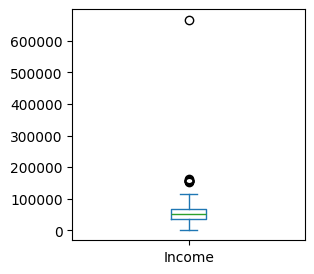

In [9]:
# salah satu cara untuk mengisi missing value yaitu dengan menggunakan mean atau median
# menggunakan mean jika hasil dari mean normal atau tidak ada titik koma
# menggunakan median jika terdapat outlier (ada perbedaan data yang jauh) atau distribusi tidak normal

# Visualisasi outlier 
data['Income'].plot(kind='box',figsize=(3,3))

# Ternyata terdapat data yang outlier sehingga lebih baik menggunakan median
# untuk mengisi missing value

In [10]:
# Median
median_Income=data['Income'].median()
print(f"Median Income: ${median_Income}")

# kode berikut merupakan kode untuk mengisi nilai yang hilang pada kolom Income
data['Income']=data['Income'].fillna(data['Income'].median())

# kemudian jika kita cek lagi maka kolon Income sudah terisi
data.isna().sum().sort_values(ascending=False)

Median Income: $51381.5


ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

#### Outliers

In [11]:
# kemudian kita ingin mengetahui nilai Outliers dari kolom-kolom yang nantinya akan dianalisa
data_to_plot = data.select_dtypes(include=['float','int'])
data_to_plot.drop(columns=['ID','AcceptedCmp3','AcceptedCmp4','AcceptedCmp5',
                           'AcceptedCmp1','AcceptedCmp2','Complain','Response'],
                    inplace=True)
data_to_plot

,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,1957,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7
1,1954,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5
2,1965,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4
3,1984,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6
4,1981,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,61223.0,0,1,46,709,43,182,42,118,247,2,9,3,4,5
2236,1946,64014.0,2,1,56,406,0,30,0,0,8,7,8,2,5,7
2237,1981,56981.0,0,0,91,908,48,217,32,12,24,1,2,3,13,6
2238,1956,69245.0,0,1,8,428,30,214,80,30,61,2,6,5,10,3


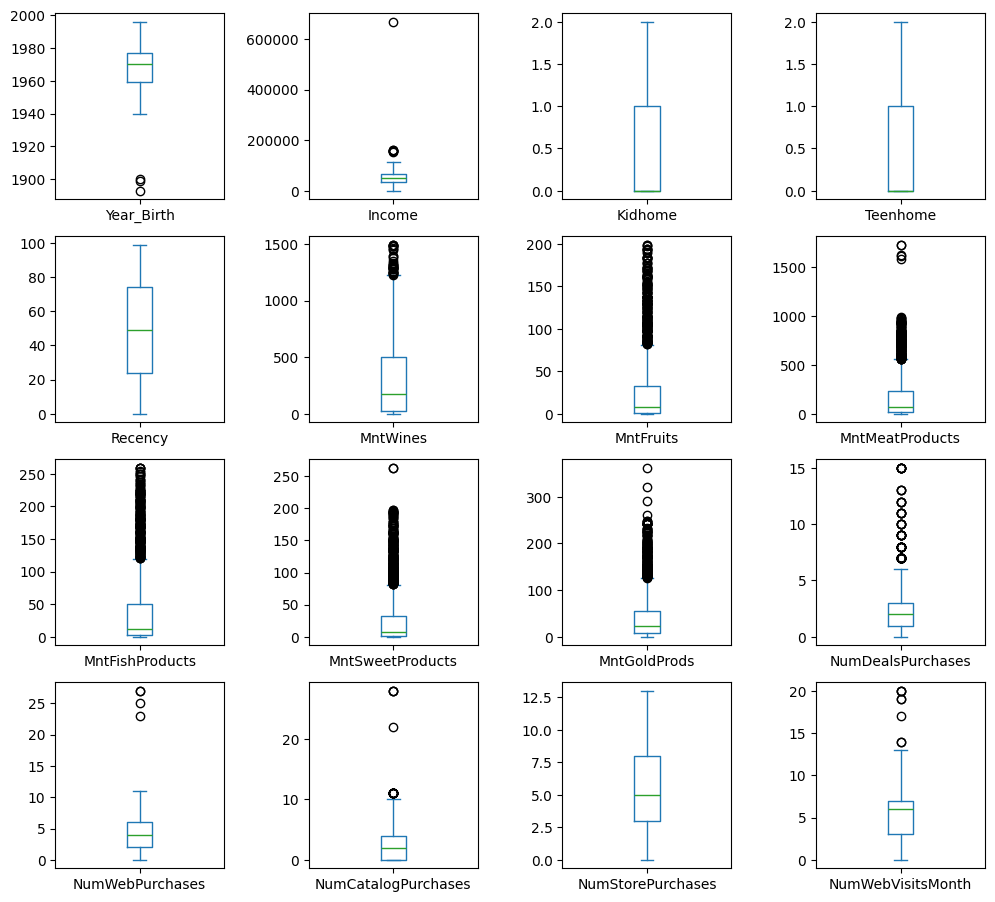

In [12]:
data_to_plot.plot(subplots=True, layout=(5,4), kind='box', figsize=(12,14))
plt.subplots_adjust(wspace=0.5)

Dari hasil di outlier pada beberapa kolom di atas terdapat beberapa kolom yang memang outliers.
Namun kolom itu masih NORMAL karena setiap customer memiliki jumlah pembelian yang berbeda, dan gaji yang berbeda.
**KECUALI feature Year-Birth** karena tedapat beberapa data yang usia kelahirannya jauh dari masa sekarang, tidak mungkin orang hidup selama 100 tahun dari 1900.

In [13]:
# maka dari itu data yang memiliki kelahiran tahun di bawah 1900 dihapus

data = data[data['Year_Birth']>1900].reset_index(drop=True)
data

#hasil dari penghapusan tersebut yang awalnya data berjumlah 2240 menjadi 2237

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,0
2233,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,0
2234,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,0
2235,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,0


### Question 3 :
Apakah tedapat distribusi yang tidak masuk akal?

In [14]:
# kita buat fungsi untuk mendefinisikan seluruh kolom yang ingin ditampilkan
# yang menggunakan numeric

numeric = data_to_plot.columns
numeric

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'],
      dtype='object')

C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\3096241900.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(bins=50, ax=ax, layout=(6,4), column=numeric)


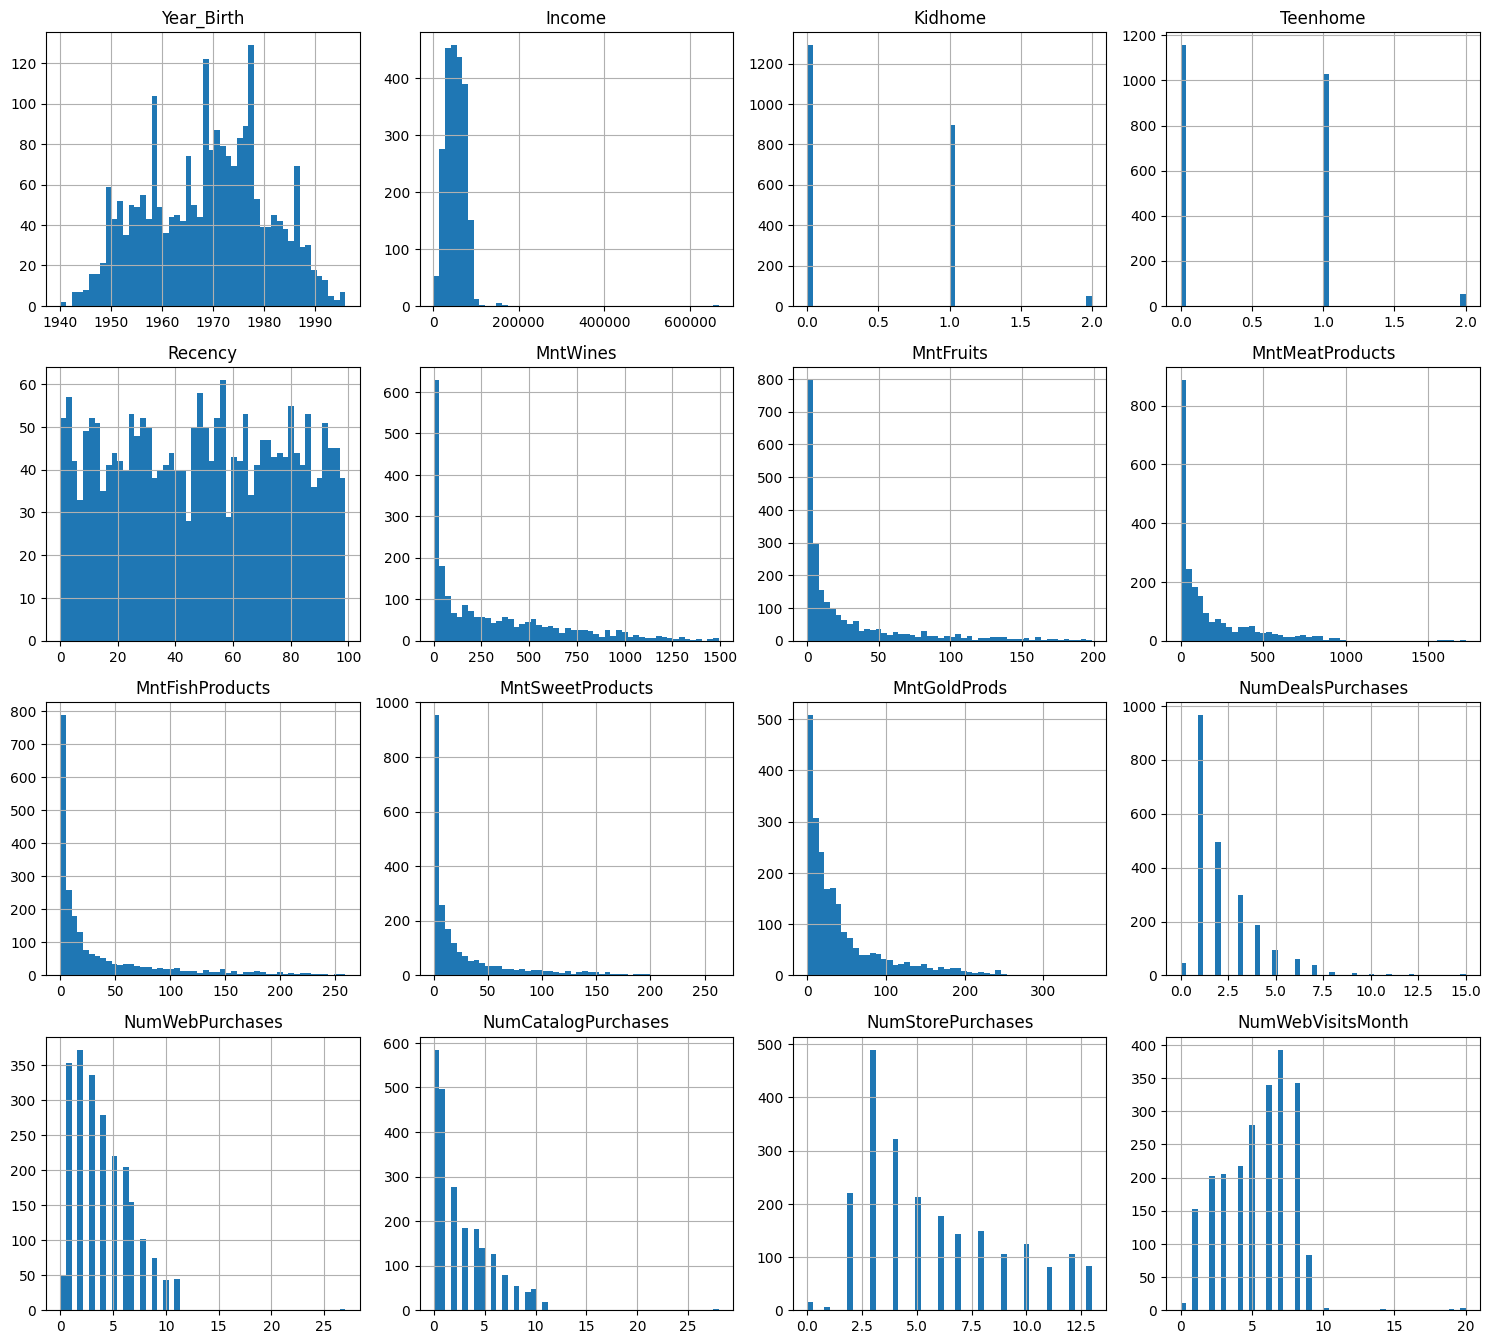

In [15]:
# kemudian kita buat tampilannya
fig = plt.figure(figsize=(15,20))
ax = plt.gca()

data.hist(bins=50, ax=ax, layout=(6,4), column=numeric)
plt.tight_layout()
plt.show()

## Data Insight

**Menampilkan Insight Dari Beberapa Features Terhadap Variabel Tujuan yaitu Response (New Campaign)**

### Menampilkan data yang telah di bersihkan

In [16]:
# Menampilkan data kolom dan baris di csv
data_after = data.copy()
data_after.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2237 non-null   int64         
 1   Year_Birth           2237 non-null   int64         
 2   Education            2237 non-null   object        
 3   Marital_Status       2237 non-null   object        
 4   Income               2237 non-null   float64       
 5   Kidhome              2237 non-null   int64         
 6   Teenhome             2237 non-null   int64         
 7   Dt_Customer          2237 non-null   datetime64[ns]
 8   Recency              2237 non-null   int64         
 9   MntWines             2237 non-null   int64         
 10  MntFruits            2237 non-null   int64         
 11  MntMeatProducts      2237 non-null   int64         
 12  MntFishProducts      2237 non-null   int64         
 13  MntSweetProducts     2237 non-nul

In [17]:
data_after

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,0
2233,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,0
2234,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,0
2235,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,0


In [18]:
# membuat sebuah fungsi untuk menampilkan % di dalam chart
def barPerc(df, xVar,ax):
    numX=len([x for x in df[xVar].unique() if x==x])
    bars=ax.patches
    for ind in range(numX):
        hueBars=bars[ind::][::numX]
        total=sum([x.get_height() for x in hueBars])
        for bar in hueBars:
            ax.text(bar.get_x()+bar.get_width()/2.,
                   bar.get_height(),
                   f'{bar.get_height()/total:.0%}',
                   ha="center",va="bottom")

In [19]:
# warna pada chart
sns.set_context('notebook')
sns.set_style('whitegrid')
sns.set_palette('Spectral')

### Customer_Age

In [20]:
# menampilkan tahun customer mendaftar
print(data_after['Dt_Customer'].dt.year,"\n")
# menampilkan tahun kelahiran
print(data_after['Year_Birth'],"\n")

# membuat feature baru 'Customer_Age' untuk mengetahui umur dari customer
data_after['Customer_Age']=data_after['Dt_Customer'].dt.year - data_after['Year_Birth']
data_after[['Customer_Age']]

0       2012
1       2014
2       2013
3       2014
4       2014
        ... 
2232    2013
2233    2014
2234    2014
2235    2014
2236    2012
Name: Dt_Customer, Length: 2237, dtype: int32 

0       1957
1       1954
2       1965
3       1984
4       1981
        ... 
2232    1967
2233    1946
2234    1981
2235    1956
2236    1954
Name: Year_Birth, Length: 2237, dtype: int64 



,Customer_Age
0,55
1,60
2,48
3,30
4,33
...,...
2232,46
2233,68
2234,33
2235,58


<Axes: xlabel='Customer_Age', ylabel='Count'>

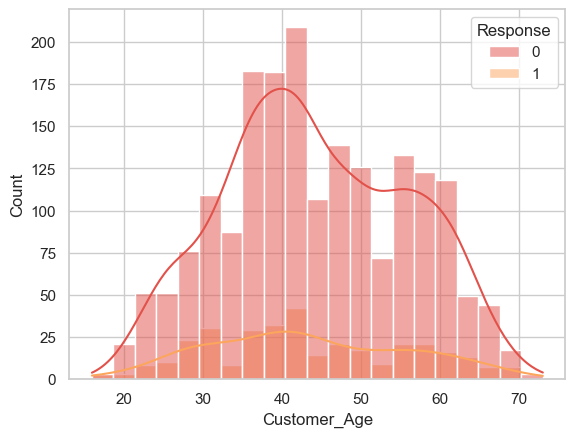

In [21]:
sns.histplot(data=data_after, x='Customer_Age', hue='Response', kde=True)

**Interpretasi Feature Customer_Age Berdasarkan Variabel Utama yaitu Response**

1. **Distribusi umur** customer **berpusat pada sekitar 35-50 tahun**.
2. Ternyata mayoritas dari customer **tidak mengikuti campaign** (tidak mengambil produk baru) dimana area merah lebih tinggi di semua rentang umur.
3. **Respons paling banyak** pada usia sekitar **35-45 tahun** menunjukkan usian menengah cenderung lebih tertarik pada campaign baru dibanding usia tua
4. Jumlah **responden di usia muda (< 30 tahun) lebih rendah**, kemungkinan kebutuhan produk belum tinggi serta **usia tua mengalami penurunan partisipasi**

**Kesimpulan**: **Campaign efektif pada customer usia dewasa menengah (usia 35-45 tahun)**, smentara usia muda dan tua menunjukkan minat lebih rendah

### Education

In [22]:
#cek data unik pada feature education
data_after.Education.unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

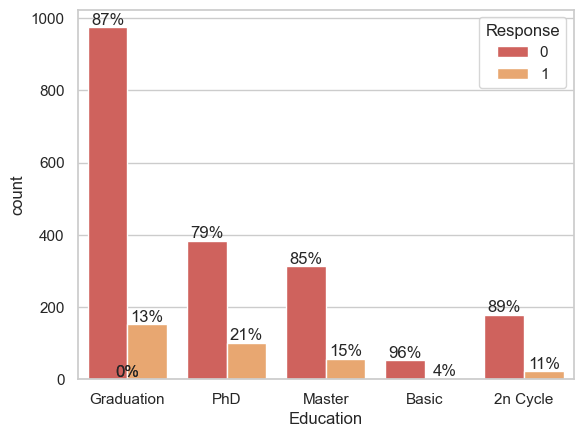

In [23]:
# tampilan feature education dalam bentuk chart
ax=sns.countplot(x='Education', hue='Response', data=data_after)
barPerc(data_after, 'Education', ax)

**Interpretasi Feature Education Berdasarkan Variabel Utama yaitu Response**

1. Segmen **2n Cycle** masih layak, namun bukan yang paling menjanjikan
2. Segmen **Basic** menunjukkan **kontribusi paling rendah dalam campaign**, kurang tertarik dengan campaign baru
3. Segmen **Graduation** memiliki jumlah **customer yang paling banyak namun conversion ratenya tidak tertinggi**, namun segmen ini tetap penting.
4. Segmen **Master** lebih baik dari graduation dan customer cukup terbuka terhadap data baru namun jumlah customer sedikit. 
5. Segmen **PhD** **paling responsif terhadap campaign**, menjadikan **target prioritas utama**.

**Kesimpulan**: Yang **paling potensial mengikuti campaign** yaitu pada pendidikan **PhD**, diikuti dengan Master dan Graduation

### Korelasi Education dan Income

(0.0, 175000.0)

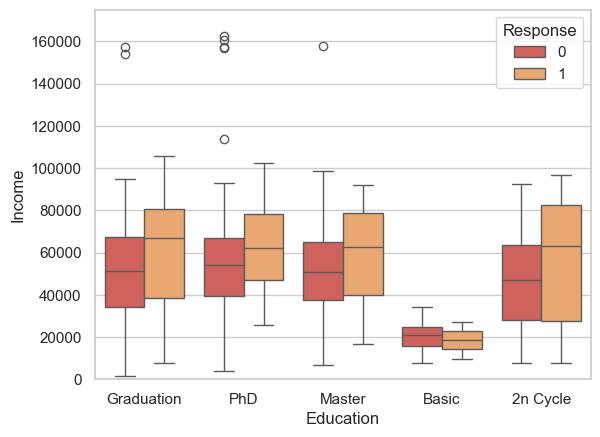

In [24]:
sns.boxplot(data=data_after, x='Education', y='Income', hue='Response')
plt.ylim(0, 175000)

**Interpretasi Feature Income dari latar belakang Education Berdasarkan Variabel Utama yaitu Response**

1. Terdapat Insight menarik dimana **setiap customer yang mengikuti campaign median Income nya lebih tinggi** daripada yang tidak ikut campaign
2. Contoh pada customer terbanyak yaitu Graduation, **walaupun sama lulusan S1** namun customer **yang mengikuti campaign** rata-rata (garis tengah di dalam kotak) **memiliki Income yang lebih tinggi** daripada sejawatnya.

**Kesimpulan**: 
**Semakin tinggi Income** yang dimiliki customer, **semakin besar kemungkinan ikut campaign**.

### Marital_Status

In [25]:
# cek data unik feature Marital_Status
data_after.Marital_Status.unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [26]:
# penggabungan beberapa kategori Marital_Status untuk mempermudah analisa
data_after['Marital_Status'] = data_after['Marital_Status'].apply(
    lambda x: 'Single' if str(x) in ['YOLO', 'Alone', 'Absurd']
    else 'Married' if str(x) == 'Together'
    else 'Widow' if str(x) == 'Divorced'
    else str(x)
)

# cek data unik setelah penggabungan
data_after.Marital_Status.unique()

array(['Single', 'Married', 'Widow'], dtype=object)

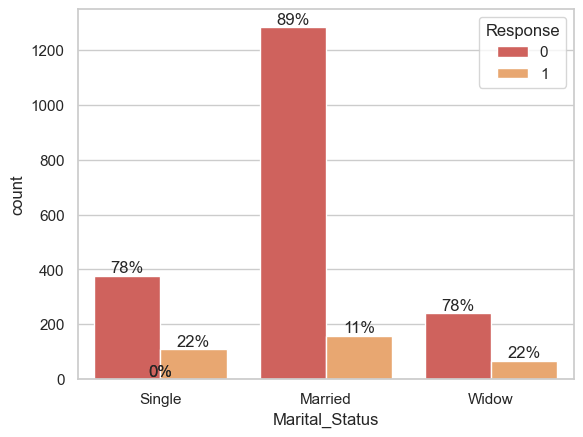

In [27]:
# tampilan chart Marita_Status
ax=sns.countplot(x='Marital_Status', hue='Response', data=data_after)
barPerc(data_after, 'Marital_Status', ax)

**Interpretasi Feature Marital_Status Berdasarkan Variabel Utama yaitu Response**

1. Customer **paling banyak berstatus married** dan **sebagian besar tidak mengikuti campaign**, serta memiliki tingkat partisipasi paling rendah dengan rasio 1:10 orang
2. Sekitar **1 dari 5 orang tertarik pada penawaran campaign terbaru pada kelompok single dan widow**
3. Kelompok **single dan widow memiliki ketertarikan dua kali lebih tinggi** dibanding married 

**Kesimpulan**: Marital Status berpengaruh terhadap kemungkinan mengikuti campaign dengan **single dan widow lebih responsif dibanding married**.

### Num_Dependants

In [28]:
# membuat feature baru 'Num_Dependants' untuk menghitung jumlah anak yang dimiliki customer
data_after['Num_Dependants'] = data_after['Kidhome'] + data_after['Teenhome']
data_after[['Kidhome', 'Teenhome', 'Num_Dependants']]

,Kidhome,Teenhome,Num_Dependants
0,0,0,0
1,1,1,2
2,0,0,0
3,1,0,1
4,1,0,1
...,...,...,...
2232,0,1,1
2233,2,1,3
2234,0,0,0
2235,0,1,1


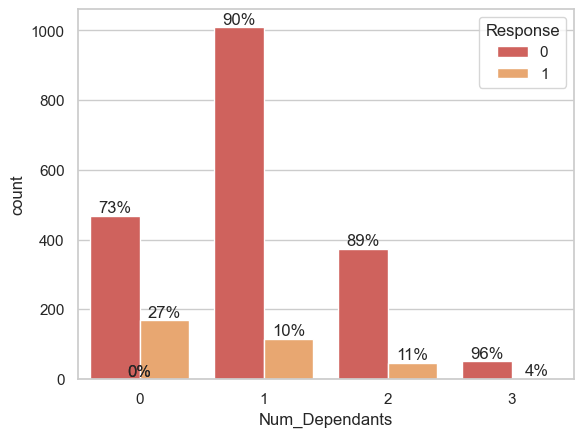

In [29]:
# chart Num_Dependants
ax=sns.countplot(x='Num_Dependants', hue='Response', data=data_after)
barPerc(data_after, 'Num_Dependants', ax)

**Interpretasi Feature Num_Dependants Berdasarkan Variabel Utama yaitu Response**

1. Rasio dan **jumlah response tertinggi pada customer yang tidak mempunyai anak** atau berstatus single dengan rasio 1:3
2. Customer yang **memiliki 2 anak cenderung lebih memilih campaign** daripada yang memiliki 1 anak **namun response masih sama rendah**
3. Customer yang **memiliki anak lebih dari 2 tidak tertarik pada campaign**

**Kesimpulan**: Customer yang **tidak memiliki anak atau single cenderung positif terhadap campaign** / **semakin banyak jumlah anak, semakin rendah kemungkinan tidak mengikuti campaign**

### Dt_Customer_Month & Year

In [30]:
# membuat 2 feature baru month dan year untuk mengetahui tanggal customer join
data_after['Dt_Customer_Month'] = data_after['Dt_Customer'].dt.month
data_after['Dt_Customer_Year'] = data_after['Dt_Customer'].dt.year

data_after[['Dt_Customer_Month', 'Dt_Customer_Year']]

,Dt_Customer_Month,Dt_Customer_Year
0,9,2012
1,3,2014
2,8,2013
3,2,2014
4,1,2014
...,...,...
2232,6,2013
2233,6,2014
2234,1,2014
2235,1,2014


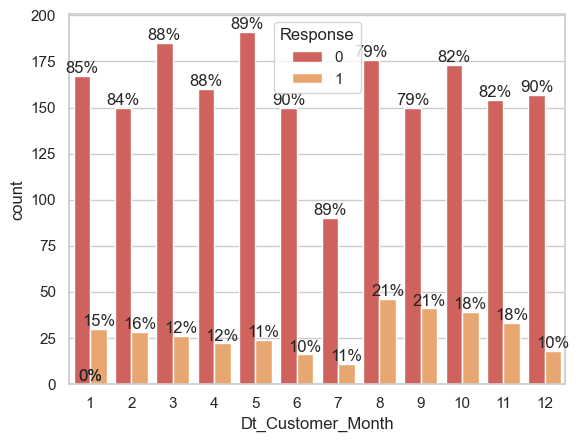

In [31]:
# chart Dt_Customer_Month
ax=sns.countplot(x='Dt_Customer_Month', hue='Response', data=data_after)
barPerc(data_after, 'Dt_Customer_Month', ax)

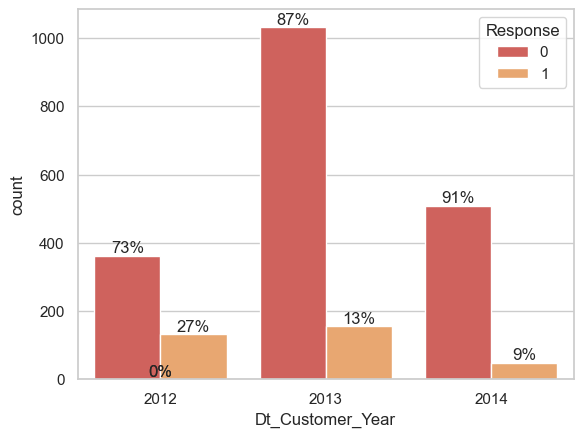

In [32]:
# chart Dt_Customer_Year
ax=sns.countplot(x='Dt_Customer_Year', hue='Response', data=data_after)
barPerc(data_after, 'Dt_Customer_Year', ax)

**Interpretasi Feature Dt_Customer_Month & Year Berdasarkan Variabel Utama yaitu Response**

1. Customer yang **mendaftar lebih lama** untuk berbelanja, **berpeluang tertarik pada produk baru**.
2. Terjadi **penurunan signifikan di tahun 2013** dimana hanya sekitar **1 dari 8 orang yang merespon positif (ikut campaign)**.
3. Customer join tahun 2014 semakin rendah tingkat response untuk mengikuti campaign

**Kesimpulan**: **Semakin lama customer yang bergabung, semakin tinggi kemungkinan mengikuti campaign**

### Recency

<Axes: xlabel='Recency', ylabel='Count'>

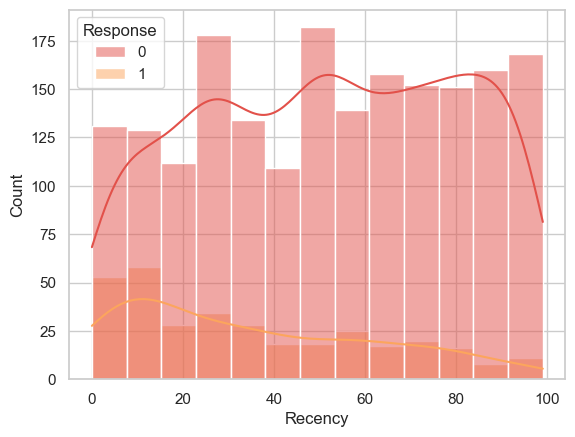

In [33]:
# chart Recency
sns.histplot(data=data_after, x='Recency', hue='Response', kde=True)

**Interpretasi Feature Recency Berdasarkan Variabel Utama yaitu Response**

1. **Recency** merupakan **berapa lama (hari) sejak pelanggan terakhir belanja**, semakin kecil diagram semakin baru belanja, semakin besar sudah lama tidak belanja
2. **Respon oranye (ikut campaign) lebih banyak di recency 0-30 hari**, semakin ke kanan recency respon makin menurun
3. **Semakin lama tidak belanja, peluang ikut campaign makin kecil**

**Kesimpulan**: **Customer yang baru belanja berpotensi ikut campaign**, pelanggan yang sudah tidak lama belanja cenderung tidak merespon.

### Total Amount Spent

In [34]:
# menghitung perbandingan jumlah pembelian produk (yang terdapat 'Mnt' di kolomnya)
amt_spent_features = [c for c in data_after.columns if 'Mnt' in str(c)]
amt_spent_features.append('Response')

data_after[amt_spent_features].corr()[['Response']].sort_values(by='Response', ascending=False)

,Response
Response,1.000000
MntWines,0.247392
MntMeatProducts,0.236640
MntGoldProds,0.140693
MntFruits,0.125904
MntSweetProducts,0.117366
MntFishProducts,0.111415


<Axes: xlabel='Total_Amount_Spent', ylabel='Count'>

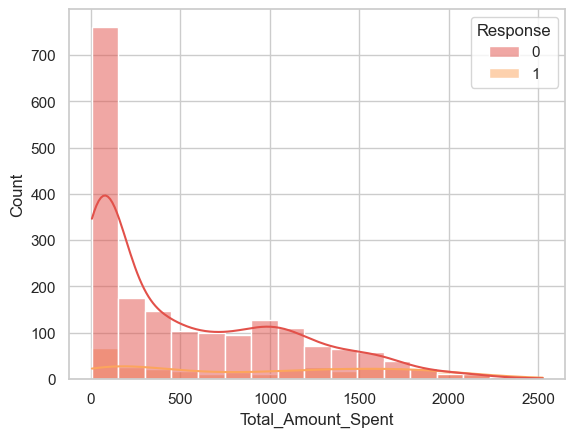

In [35]:
# membuat feature baru 'Total_Amount_Spent' untuk menghitung jumlah total pembelian produk setiap customer
amt_spent_features = [c for c in data_after.columns if 'Mnt' in str(c)]
data_after['Total_Amount_Spent']=data_after[amt_spent_features].sum(axis=1)
sns.histplot(data=data_after, kde=True, x='Total_Amount_Spent', hue='Response')

**Interpretasi Feature Total_Amount_Spent Berdasarkan Variabel Utama yaitu Response**

1. Customer dengan **probabilitas tertinggi terhadap campaign yaitu yang membeli produk Wines dan Meat**
2. **Sebagian besar customer belanja di bawah 500 dolar**, dan rata-rata **tidak memilih ikut campaign**.
3. Customer yang **mengikuti campaign lebih stabil** dan bertahan **ketika belanja di atas 1000 hingga 2000 dolar**.

**Kesimpulan**: **Customer yang menghabiskan lebih banyak total belanja, semakin besar kemungkinan untuk ikut campaign**

### Purchases🤷‍♀️

In [36]:
purchase_feature = [d for d in data_after.columns if 'Purchase' in str(d)]
purchase_feature.append('Response')

data_after[purchase_feature].corr()[['Response']].sort_values(by='Response', ascending=False)

,Response
Response,1.000000
NumCatalogPurchases,0.220894
NumWebPurchases,0.148453
NumStorePurchases,0.038855
NumDealsPurchases,0.001854


### AcceptedCmp

In [37]:
# menghitung nilai korelasi customer yang join campaign sebelumnya terhadap response (campaign baru)
Prev_Camp = [e for e in data_after.columns if 'AcceptedCmp' in str(e)]
Prev_Camp.append('Response')

data_after[Prev_Camp].corr()[['Response']].sort_values(by='Response', ascending=False)

,Response
Response,1.000000
AcceptedCmp5,0.328182
AcceptedCmp1,0.293882
AcceptedCmp3,0.254144
AcceptedCmp4,0.176890
AcceptedCmp2,0.169249


**Interpretasi Kolom AcceptedCamp Berdasarkan Variabel Utama yaitu Response**

1. Tabel di atas merupakan nilai **korelasi antara campaign dengan variabel response**.
2. Angka ini menjelaskan **seberapa besar pengaruh riwayat pelanggan saat menerima campaign sebelumnya terhadap keputusan mereka untuk ikut di campaign terbaru**.
3. **Campaign 5 merupakan prediktor terbaik** dimana customer **memiliki kecenderungan untuk tertarik pada produk baru**. Diikuti customer yang mengikuti campaign 1 dan 3
 
**Kesimpulan**: **Customer yang paling berpotensi** untuk **mengikuti campaign baru** yaitu **yang pernah mengikuti campaign 5, 1 dan 3**

### Simpan Data

In [38]:
print("HASIL AKHIR VERIFIKASI\n")
print(f"Shape Akhir: {data_after.shape} \n")
print(f"Tipe Data:\n{data_after.dtypes}\n")
data_after

HASIL AKHIR VERIFIKASI

Shape Akhir: (2237, 32) 

Tipe Data:
ID                              int64
Year_Birth                      int64
Education                      object
Marital_Status                 object
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2               

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,55,0,9,2012,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,2,3,2014,27
2,4141,1965,Graduation,Married,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,48,0,8,2013,776
3,6182,1984,Graduation,Married,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,1,2,2014,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,1,1,2014,422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,0,46,1,6,2013,1341
2233,4001,1946,PhD,Married,64014.0,2,1,2014-06-10,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,0,68,3,6,2014,444
2234,7270,1981,Graduation,Widow,56981.0,0,0,2014-01-25,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,0,33,0,1,2014,1241
2235,8235,1956,Master,Married,69245.0,0,1,2014-01-24,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,0,58,1,1,2014,843


In [39]:
data_after.to_csv('Clean_Data_Campaign.csv', index=False)
print("File berhasil disimpan")

File berhasil disimpan


## Model (Train, Val, Test)

### Data Splitting

In [40]:
# import library
from sklearn.model_selection import train_test_split

In [41]:
# membaca file csv
model = pd.read_csv('Clean_Data_Campaign.csv')
model.shape

(2237, 32)

In [42]:
model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2237 non-null   int64  
 1   Year_Birth           2237 non-null   int64  
 2   Education            2237 non-null   object 
 3   Marital_Status       2237 non-null   object 
 4   Income               2237 non-null   float64
 5   Kidhome              2237 non-null   int64  
 6   Teenhome             2237 non-null   int64  
 7   Dt_Customer          2237 non-null   object 
 8   Recency              2237 non-null   int64  
 9   MntWines             2237 non-null   int64  
 10  MntFruits            2237 non-null   int64  
 11  MntMeatProducts      2237 non-null   int64  
 12  MntFishProducts      2237 non-null   int64  
 13  MntSweetProducts     2237 non-null   int64  
 14  MntGoldProds         2237 non-null   int64  
 15  NumDealsPurchases    2237 non-null   i

In [43]:
# mengubah tipe data Dt_Customer menjadi datetime
model['Dt_Customer'] = pd.to_datetime(model['Dt_Customer'])

In [44]:
model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2237 non-null   int64         
 1   Year_Birth           2237 non-null   int64         
 2   Education            2237 non-null   object        
 3   Marital_Status       2237 non-null   object        
 4   Income               2237 non-null   float64       
 5   Kidhome              2237 non-null   int64         
 6   Teenhome             2237 non-null   int64         
 7   Dt_Customer          2237 non-null   datetime64[ns]
 8   Recency              2237 non-null   int64         
 9   MntWines             2237 non-null   int64         
 10  MntFruits            2237 non-null   int64         
 11  MntMeatProducts      2237 non-null   int64         
 12  MntFishProducts      2237 non-null   int64         
 13  MntSweetProducts     2237 non-nul

In [45]:
# membagi data menjadi train, val, test
model_full_train, model_test = train_test_split(model, test_size=0.2, random_state=1)
model_train, model_valid = train_test_split(model_full_train, test_size=0.25, random_state=1)
model_train.shape, model_valid.shape, model_test.shape

((1341, 32), (448, 32), (448, 32))

### Preprocessing

preprocessing dibagi menjadi 2 yaitu data yang mengandung numeric dan kategori

#### Numeric preprocessing

In [46]:
print('Train')
display(model_train)
print('\n\nValid')
display(model_valid)
print('\n\nTest')
display(model_test)

Train


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
1034,67,1972,Master,Single,46423.0,1,1,2013-09-18,6,68,0,16,0,0,8,3,2,0,4,7,0,0,0,0,0,0,0,41,2,9,2013,92
2154,1515,1975,Master,Married,34176.0,0,1,2014-01-22,9,11,2,7,4,2,2,1,1,0,3,3,0,0,0,0,0,0,0,39,1,1,2014,28
81,2261,1969,Graduation,Married,26304.0,1,0,2013-06-23,5,4,1,5,2,0,4,1,1,0,2,7,0,0,0,0,0,0,0,44,1,6,2013,16
539,5036,1984,PhD,Single,42710.0,1,0,2012-11-28,38,252,3,42,4,3,102,2,4,5,3,6,0,0,0,0,0,0,0,28,1,11,2012,406
1512,2853,1980,Graduation,Single,51766.0,1,0,2014-03-11,74,60,51,87,6,20,51,2,4,2,4,5,0,0,0,0,0,0,0,34,1,3,2014,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,456,1986,2n Cycle,Married,7500.0,1,0,2013-02-07,96,1,11,5,4,6,9,2,2,0,3,8,0,0,0,0,0,0,0,27,1,2,2013,36
466,3916,1971,PhD,Married,49269.0,1,0,2012-08-15,92,639,8,166,11,8,58,3,7,3,12,7,0,0,0,0,0,0,0,41,1,8,2012,890
224,4653,1978,Graduation,Married,42011.0,1,0,2013-03-26,46,131,0,16,2,1,39,4,3,1,4,8,0,0,0,0,0,0,0,35,1,3,2013,189
1805,1619,1956,Graduation,Married,90369.0,0,0,2014-04-28,2,292,51,981,224,23,17,1,4,6,6,1,0,0,0,0,0,0,1,58,0,4,2014,1588




Valid


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
989,7378,1981,Master,Married,42021.0,1,0,2012-08-31,34,393,5,136,7,5,27,5,10,1,6,9,1,0,0,0,0,0,0,31,1,8,2012,573
2011,3262,1958,Graduation,Single,68281.0,0,0,2012-08-07,31,995,112,417,42,48,41,1,2,9,13,5,0,0,0,0,0,0,1,54,0,8,2012,1655
1149,10710,1979,Graduation,Married,7500.0,0,1,2012-08-29,61,5,2,3,3,0,5,1,1,0,2,8,0,0,0,0,0,0,0,33,1,8,2012,18
1496,6318,1988,Graduation,Married,68487.0,0,0,2013-01-13,48,758,12,385,33,89,89,1,9,7,13,4,0,0,0,0,0,0,0,25,0,1,2013,1366
657,55,1963,Graduation,Married,56253.0,0,1,2012-12-07,83,509,0,65,7,11,5,4,7,2,9,6,0,0,0,0,0,0,0,49,1,12,2012,597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,3406,1964,Graduation,Single,45989.0,0,1,2012-10-22,97,138,33,87,28,24,12,4,3,2,7,3,0,0,0,0,0,0,0,48,1,10,2012,322
452,4148,1972,Graduation,Married,38988.0,1,2,2012-08-20,90,164,24,103,12,3,42,7,5,1,6,8,0,0,0,0,0,0,0,40,3,8,2012,348
410,7422,1987,Graduation,Single,46923.0,1,0,2012-08-22,90,85,44,54,102,78,6,3,5,1,7,7,0,0,0,0,0,0,0,25,1,8,2012,369
52,1331,1977,Graduation,Single,35790.0,1,0,2013-01-02,54,12,6,20,30,1,3,2,2,0,3,7,0,0,0,0,0,0,0,36,1,1,2013,72




Test


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
1870,6715,1948,PhD,Single,60200.0,0,1,2013-01-02,3,502,19,132,0,6,26,6,6,2,11,6,0,0,0,0,0,0,0,65,1,1,2013,685
1447,5788,1972,Graduation,Married,46053.0,1,0,2013-02-17,46,56,10,92,19,7,25,3,3,2,4,5,0,0,0,0,0,0,0,41,1,2,2013,209
1138,523,1989,Graduation,Married,37155.0,1,0,2013-01-31,51,23,0,26,7,15,3,1,2,0,4,5,0,0,0,0,0,0,0,24,1,1,2013,74
535,11096,1952,2n Cycle,Married,57247.0,0,1,2013-08-08,50,99,4,32,37,54,6,2,2,1,7,2,0,0,0,0,0,0,0,61,1,8,2013,232
1577,3790,1956,Graduation,Married,34633.0,2,1,2014-01-23,31,8,1,5,0,0,1,1,1,0,2,6,0,0,0,0,0,0,0,58,3,1,2014,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,6248,1947,Master,Single,91712.0,0,0,2013-10-17,47,1276,24,746,94,29,48,0,9,7,11,3,0,0,1,0,0,0,1,66,0,10,2013,2217
2013,7042,1983,Graduation,Married,36790.0,0,0,2013-03-01,14,3,3,14,15,21,10,1,2,1,2,9,0,0,0,0,0,0,1,30,0,3,2013,66
1641,3091,1981,2n Cycle,Married,75774.0,1,0,2014-05-02,27,340,21,134,258,14,56,1,7,5,8,4,0,0,0,0,0,0,0,33,1,5,2014,823
1819,8334,1971,Master,Single,33316.0,1,1,2013-10-04,34,79,1,31,4,4,12,3,2,1,4,6,0,0,0,0,0,0,0,42,2,10,2013,131


In [47]:
# mengambil feature yang berisi data numeric saja
cmp_feat=[e for e in model.columns if 'AcceptedCmp' in str(e)]
mnt_feat=[e for e in model.columns if 'Mnt' in str(e)]
num_feat=[e for e in model.columns if 'Num' in str(e)]

In [48]:
numeric_feat = [
    'Income','Kidhome','Teenhome','Recency','Complain','Customer_Age','Num_Dependants','Dt_Customer_Month',
    'Dt_Customer_Year','Total_Amount_Spent',
]

In [49]:
all_numeric_feat = cmp_feat + mnt_feat + num_feat + numeric_feat

In [50]:
print('Train')
display(model_train[all_numeric_feat])
print('\n\nValid')
display(model_valid[all_numeric_feat])
print('\n\nTest')
display(model_test[all_numeric_feat])

Train


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Num_Dependants,Income,Kidhome,Teenhome,Recency,Complain,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
1034,0,0,0,0,0,68,0,16,0,0,8,3,2,0,4,7,2,46423.0,1,1,6,0,41,2,9,2013,92
2154,0,0,0,0,0,11,2,7,4,2,2,1,1,0,3,3,1,34176.0,0,1,9,0,39,1,1,2014,28
81,0,0,0,0,0,4,1,5,2,0,4,1,1,0,2,7,1,26304.0,1,0,5,0,44,1,6,2013,16
539,0,0,0,0,0,252,3,42,4,3,102,2,4,5,3,6,1,42710.0,1,0,38,0,28,1,11,2012,406
1512,0,0,0,0,0,60,51,87,6,20,51,2,4,2,4,5,1,51766.0,1,0,74,0,34,1,3,2014,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,0,0,0,0,0,1,11,5,4,6,9,2,2,0,3,8,1,7500.0,1,0,96,0,27,1,2,2013,36
466,0,0,0,0,0,639,8,166,11,8,58,3,7,3,12,7,1,49269.0,1,0,92,0,41,1,8,2012,890
224,0,0,0,0,0,131,0,16,2,1,39,4,3,1,4,8,1,42011.0,1,0,46,0,35,1,3,2013,189
1805,0,0,0,0,0,292,51,981,224,23,17,1,4,6,6,1,0,90369.0,0,0,2,0,58,0,4,2014,1588




Valid


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Num_Dependants,Income,Kidhome,Teenhome,Recency,Complain,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
989,1,0,0,0,0,393,5,136,7,5,27,5,10,1,6,9,1,42021.0,1,0,34,0,31,1,8,2012,573
2011,0,0,0,0,0,995,112,417,42,48,41,1,2,9,13,5,0,68281.0,0,0,31,0,54,0,8,2012,1655
1149,0,0,0,0,0,5,2,3,3,0,5,1,1,0,2,8,1,7500.0,0,1,61,0,33,1,8,2012,18
1496,0,0,0,0,0,758,12,385,33,89,89,1,9,7,13,4,0,68487.0,0,0,48,0,25,0,1,2013,1366
657,0,0,0,0,0,509,0,65,7,11,5,4,7,2,9,6,1,56253.0,0,1,83,0,49,1,12,2012,597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,0,0,0,0,0,138,33,87,28,24,12,4,3,2,7,3,1,45989.0,0,1,97,0,48,1,10,2012,322
452,0,0,0,0,0,164,24,103,12,3,42,7,5,1,6,8,3,38988.0,1,2,90,0,40,3,8,2012,348
410,0,0,0,0,0,85,44,54,102,78,6,3,5,1,7,7,1,46923.0,1,0,90,0,25,1,8,2012,369
52,0,0,0,0,0,12,6,20,30,1,3,2,2,0,3,7,1,35790.0,1,0,54,0,36,1,1,2013,72




Test


,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Num_Dependants,Income,Kidhome,Teenhome,Recency,Complain,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
1870,0,0,0,0,0,502,19,132,0,6,26,6,6,2,11,6,1,60200.0,0,1,3,0,65,1,1,2013,685
1447,0,0,0,0,0,56,10,92,19,7,25,3,3,2,4,5,1,46053.0,1,0,46,0,41,1,2,2013,209
1138,0,0,0,0,0,23,0,26,7,15,3,1,2,0,4,5,1,37155.0,1,0,51,0,24,1,1,2013,74
535,0,0,0,0,0,99,4,32,37,54,6,2,2,1,7,2,1,57247.0,0,1,50,0,61,1,8,2013,232
1577,0,0,0,0,0,8,1,5,0,0,1,1,1,0,2,6,3,34633.0,2,1,31,0,58,3,1,2014,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0,0,1,0,0,1276,24,746,94,29,48,0,9,7,11,3,0,91712.0,0,0,47,0,66,0,10,2013,2217
2013,0,0,0,0,0,3,3,14,15,21,10,1,2,1,2,9,0,36790.0,0,0,14,0,30,0,3,2013,66
1641,0,0,0,0,0,340,21,134,258,14,56,1,7,5,8,4,1,75774.0,1,0,27,0,33,1,5,2014,823
1819,0,0,0,0,0,79,1,31,4,4,12,3,2,1,4,6,2,33316.0,1,1,34,0,42,2,10,2013,131


In [51]:
model_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1341 entries, 1034 to 185
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   1341 non-null   int64         
 1   Year_Birth           1341 non-null   int64         
 2   Education            1341 non-null   object        
 3   Marital_Status       1341 non-null   object        
 4   Income               1341 non-null   float64       
 5   Kidhome              1341 non-null   int64         
 6   Teenhome             1341 non-null   int64         
 7   Dt_Customer          1341 non-null   datetime64[ns]
 8   Recency              1341 non-null   int64         
 9   MntWines             1341 non-null   int64         
 10  MntFruits            1341 non-null   int64         
 11  MntMeatProducts      1341 non-null   int64         
 12  MntFishProducts      1341 non-null   int64         
 13  MntSweetProducts     1341 non-null  

#### Categoric preprocessing

In [52]:
# dalam categoric preprocessing perlu dilakukan pengubahan data menjadi numerik/angka
categoric_feat = ['Education', 'Marital_Status']

In [53]:
# gabungkan all feature 
all_feat = categoric_feat + all_numeric_feat

In [54]:
model_train_final = model_train[all_feat]
model_valid_final = model_valid[all_feat]
model_test_final = model_test[all_feat]

Kategori:
- Education (ordinal/memiliki tingkatan tertentu)
- Marital_Status (nominal/pelabelan)

In [55]:
model_train.Education.unique()

array(['Master', 'Graduation', 'PhD', '2n Cycle', 'Basic'], dtype=object)

In [56]:
# beri tingkatan dari masing-masing pendidikan
education = {'2n Cycle':1, 'Basic':2, 'Graduation':3, 'Master':4, 'PhD':5}

In [57]:
model_train_final['Education'] = model_train_final['Education'].map(education)
model_valid_final['Education'] = model_valid_final['Education'].map(education)
model_test_final['Education'] = model_test_final['Education'].map(education)

C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\4185756872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_train_final['Education'] = model_train_final['Education'].map(education)
C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\4185756872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_valid_final['Education'] = model_valid_final['Education'].map(education)
C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\4185756872.py:3: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [58]:
model_train_final

,Education,Marital_Status,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Num_Dependants,Income,Kidhome,Teenhome,Recency,Complain,Customer_Age,Num_Dependants,Dt_Customer_Month,Dt_Customer_Year,Total_Amount_Spent
1034,4,Single,0,0,0,0,0,68,0,16,0,0,8,3,2,0,4,7,2,46423.0,1,1,6,0,41,2,9,2013,92
2154,4,Married,0,0,0,0,0,11,2,7,4,2,2,1,1,0,3,3,1,34176.0,0,1,9,0,39,1,1,2014,28
81,3,Married,0,0,0,0,0,4,1,5,2,0,4,1,1,0,2,7,1,26304.0,1,0,5,0,44,1,6,2013,16
539,5,Single,0,0,0,0,0,252,3,42,4,3,102,2,4,5,3,6,1,42710.0,1,0,38,0,28,1,11,2012,406
1512,3,Single,0,0,0,0,0,60,51,87,6,20,51,2,4,2,4,5,1,51766.0,1,0,74,0,34,1,3,2014,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,1,Married,0,0,0,0,0,1,11,5,4,6,9,2,2,0,3,8,1,7500.0,1,0,96,0,27,1,2,2013,36
466,5,Married,0,0,0,0,0,639,8,166,11,8,58,3,7,3,12,7,1,49269.0,1,0,92,0,41,1,8,2012,890
224,3,Married,0,0,0,0,0,131,0,16,2,1,39,4,3,1,4,8,1,42011.0,1,0,46,0,35,1,3,2013,189
1805,3,Married,0,0,0,0,0,292,51,981,224,23,17,1,4,6,6,1,0,90369.0,0,0,2,0,58,0,4,2014,1588


In [59]:
# untuk Marital_Status digunakan metode one hot encoding untuk mengetahui label apa yang dimiliki id tersebut
from sklearn.feature_extraction import DictVectorizer

In [60]:
dv = DictVectorizer(sparse=False) 

In [61]:
model_train_final_dicts = model_train_final.to_dict(orient='records')
model_valid_final_dicts = model_valid_final.to_dict(orient='records')
model_test_final_dicts = model_test_final.to_dict(orient='records')

C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\3797201150.py:1: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  model_train_final_dicts = model_train_final.to_dict(orient='records')
C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\3797201150.py:2: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  model_valid_final_dicts = model_valid_final.to_dict(orient='records')
C:\Users\Isyad\AppData\Local\Temp\ipykernel_19272\3797201150.py:3: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  model_test_final_dicts = model_test_final.to_dict(orient='records')


In [62]:
# tampilkan 2 data saja
model_train_final_dicts[0:2]

[{'Education': 4,
  'Marital_Status': 'Single',
  'AcceptedCmp3': 0,
  'AcceptedCmp4': 0,
  'AcceptedCmp5': 0,
  'AcceptedCmp1': 0,
  'AcceptedCmp2': 0,
  'MntWines': 68,
  'MntFruits': 0,
  'MntMeatProducts': 16,
  'MntFishProducts': 0,
  'MntSweetProducts': 0,
  'MntGoldProds': 8,
  'NumDealsPurchases': 3,
  'NumWebPurchases': 2,
  'NumCatalogPurchases': 0,
  'NumStorePurchases': 4,
  'NumWebVisitsMonth': 7,
  'Num_Dependants': 2,
  'Income': 46423.0,
  'Kidhome': 1,
  'Teenhome': 1,
  'Recency': 6,
  'Complain': 0,
  'Customer_Age': 41,
  'Dt_Customer_Month': 9,
  'Dt_Customer_Year': 2013,
  'Total_Amount_Spent': 92},
 {'Education': 4,
  'Marital_Status': 'Married',
  'AcceptedCmp3': 0,
  'AcceptedCmp4': 0,
  'AcceptedCmp5': 0,
  'AcceptedCmp1': 0,
  'AcceptedCmp2': 0,
  'MntWines': 11,
  'MntFruits': 2,
  'MntMeatProducts': 7,
  'MntFishProducts': 4,
  'MntSweetProducts': 2,
  'MntGoldProds': 2,
  'NumDealsPurchases': 1,
  'NumWebPurchases': 1,
  'NumCatalogPurchases': 0,
  'NumSto

In [63]:
model_train_final_dicts = dv.fit_transform(model_train_final_dicts)

In [64]:
model_valid_final_dicts = dv.transform(model_valid_final_dicts)
model_test_final_dicts = dv.transform(model_test_final_dicts)

In [65]:
model_train_final_dicts

array([[0.000e+00, 0.000e+00, 0.000e+00, ..., 6.000e+00, 1.000e+00,
        9.200e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 9.000e+00, 1.000e+00,
        2.800e+01],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 5.000e+00, 0.000e+00,
        1.600e+01],
       ...,
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 4.600e+01, 0.000e+00,
        1.890e+02],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 2.000e+00, 0.000e+00,
        1.588e+03],
       [0.000e+00, 0.000e+00, 0.000e+00, ..., 4.500e+01, 0.000e+00,
        5.000e+01]], shape=(1341, 30))

In [66]:
model_train_final = pd.DataFrame(model_train_final_dicts, columns = dv.get_feature_names_out())
model_train_final.head()

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Complain,Customer_Age,Dt_Customer_Month,Dt_Customer_Year,Education,Income,Kidhome,Marital_Status=Married,Marital_Status=Single,Marital_Status=Widow,MntFishProducts,MntFruits,MntGoldProds,MntMeatProducts,MntSweetProducts,MntWines,NumCatalogPurchases,NumDealsPurchases,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Num_Dependants,Recency,Teenhome,Total_Amount_Spent
0,0.0,0.0,0.0,0.0,0.0,0.0,41.0,9.0,2013.0,4.0,46423.0,1.0,0.0,1.0,0.0,0.0,0.0,8.0,16.0,0.0,68.0,0.0,3.0,4.0,2.0,7.0,2.0,6.0,1.0,92.0
1,0.0,0.0,0.0,0.0,0.0,0.0,39.0,1.0,2014.0,4.0,34176.0,0.0,1.0,0.0,0.0,4.0,2.0,2.0,7.0,2.0,11.0,0.0,1.0,3.0,1.0,3.0,1.0,9.0,1.0,28.0
2,0.0,0.0,0.0,0.0,0.0,0.0,44.0,6.0,2013.0,3.0,26304.0,1.0,1.0,0.0,0.0,2.0,1.0,4.0,5.0,0.0,4.0,0.0,1.0,2.0,1.0,7.0,1.0,5.0,0.0,16.0
3,0.0,0.0,0.0,0.0,0.0,0.0,28.0,11.0,2012.0,5.0,42710.0,1.0,0.0,1.0,0.0,4.0,3.0,102.0,42.0,3.0,252.0,5.0,2.0,3.0,4.0,6.0,1.0,38.0,0.0,406.0
4,0.0,0.0,0.0,0.0,0.0,0.0,34.0,3.0,2014.0,3.0,51766.0,1.0,0.0,1.0,0.0,6.0,51.0,51.0,87.0,20.0,60.0,2.0,2.0,4.0,4.0,5.0,1.0,74.0,0.0,275.0


In [67]:
model_valid_final = pd.DataFrame(model_valid_final_dicts, columns = dv.get_feature_names_out())
model_test_final = pd.DataFrame(model_test_final_dicts, columns = dv.get_feature_names_out())

### Klasifikasi Base Model

In [68]:
# dalam pemodelan membutuhkan variabel X dan y
# X merupakan independent variabel (semua feature yang digunakan untuk prediktor)
# y merupakan dependent variabel (target) yang mana yaitu merupakan feature Response
X_train_final = model_train_final
X_valid_final = model_valid_final
X_test_final = model_test_final

In [69]:
X_train_final.shape

(1341, 30)

In [70]:
X_test_final.shape

(448, 30)

In [71]:
y_train_final = model_train.Response
y_valid_final = model_valid.Response
y_test_final = model_test.Response

#### Logistic Regresion

In [72]:
from sklearn.linear_model import LogisticRegression
# metrik untuk hasil klasifikasi
from sklearn.metrics import roc_auc_score

In [73]:
# melakukan prediksi
modelLR = LogisticRegression(random_state=42)
modelLR.fit(X_train_final, y_train_final)

C:\Users\Isyad\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [76]:
# hasil probabilitas dengan mengambil probabilitas yang positif / 1 (ikut campaign)
y_valid_pred = modelLR.predict_proba(X_valid_final)[:,1]

In [80]:
# hasil prediksi 
print('LR ROCAUC Result:', roc_auc_score(y_valid_final, y_valid_pred))

LR ROCAUC Result: 0.7622477213541667


#### Random Forest

In [81]:
from sklearn.ensemble import RandomForestClassifier

In [82]:
modelRF = RandomForestClassifier(random_state=42)
modelRF.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [83]:
# semakin tinggi hasil ROCAUC maka model semakin bagus
y_valid_pred = modelRF.predict_proba(X_valid_final)[:,1]
print('RF ROCAUC Result:', roc_auc_score(y_valid_final, y_valid_pred))

RF ROCAUC Result: 0.8835856119791667


#### Performance Stability Check

In [84]:
# menggunakan RandomForest sebagai evaluasi pada dataset tes
# karena mendapatkan ROCAUC yang lebih tinggi
x_full_train_final = pd.concat([X_train_final, X_valid_final])
y_full_train_final = pd.concat([y_train_final, y_valid_final])

In [85]:
modelRF = RandomForestClassifier(random_state=42)
modelRF.fit(X_train_final, y_train_final)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [86]:
y_test_pred = modelRF.predict_proba(X_test_final)[:,1]
print('RF ROCAUC Result:', roc_auc_score(y_test_final, y_test_pred))
# hasil ROCAUC testing turun sedikit namun masih stabil tidak terlalu jauh 
# dengan hasil ROCAUC validasi

RF ROCAUC Result: 0.8726393188854489


# Interpretasi

In [87]:
import shap

In [88]:
# menghitung shap values
explainer = shap.TreeExplainer(modelRF)
shap_values = explainer.shap_values(X_test_final)

In [89]:
# Cek bentuk shap_values dan X_test_final
print("Jumlah fitur di X_test_final:", X_test_final.shape[1])
print("Jumlah fitur di shap_values[1]:", shap_values[1].shape[1])
print("Jumlah fitur di shap_values[0]:", shap_values[0].shape[1])

# Cek jumlah total shap_values
print("Panjang shap_values:", len(shap_values))

Jumlah fitur di X_test_final: 30
Jumlah fitur di shap_values[1]: 2
Jumlah fitur di shap_values[0]: 2
Panjang shap_values: 448


In [90]:
print(shap_values.shape)
print(X_test_final.shape)

(448, 30, 2)
(448, 30)


Bentuk shap_values untuk kelas 1: (448, 30)


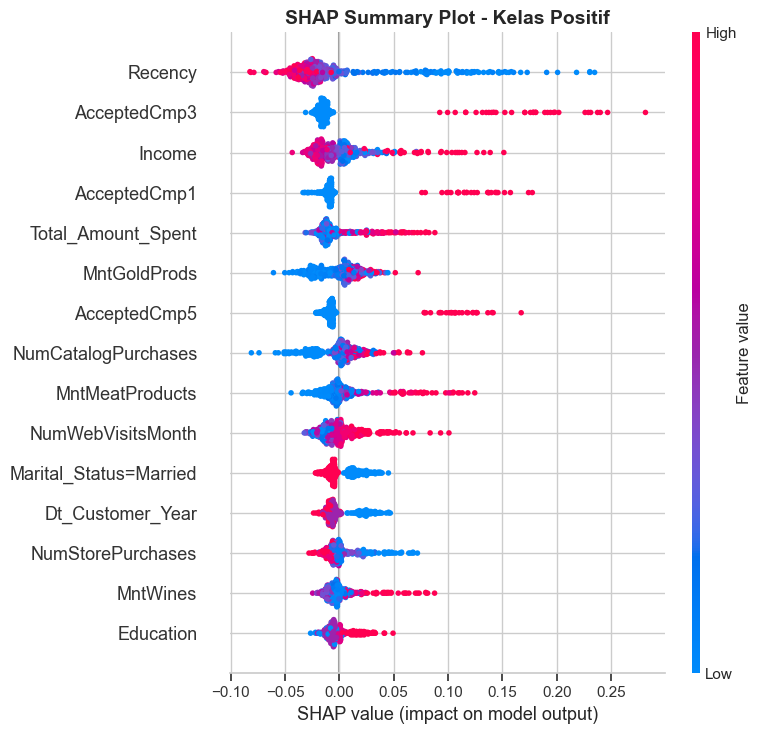

In [96]:
import matplotlib.pyplot as plt

# Memilih nilai SHAP untuk kelas positif (misal, kelas 1)
shap_values_kelas_1 = shap_values[:, :, 1]

print("Bentuk shap_values untuk kelas 1:", shap_values_kelas_1.shape)  # Akan menghasilkan (447, 33)

# Sekarang buat plot dengan matrix yang sudah sesuai
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_kelas_1, X_test_final, max_display=15, show=False)
plt.title("SHAP Summary Plot - Kelas Positif", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()